In [1]:
import time
start_time=time.time()

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
import astropy.units as u
from matplotlib import pyplot as plt
import corner
import json
from astropy.io import fits
from lmfit.model import save_modelresult
import math

# Add path to py_modules 
sys.path.append(str(Path().resolve() / 'py_modules')) # 1 level up = project root

In [3]:
from pipeline_config import MAPS_DIR

In [4]:
data_all = [
    'KPNO-M42-H-bin0',
    'KPNO-M42-N-bin0',
    'KPNO-M42-O-bin0',
    'KPNO-M42-S-bin0',
#    'MUSE-M42-Ar-bin0',
]


# Custom labels dictionary
labels_dict = {
    'KPNO-M42-H-bin0': r'H$\alpha$',
    'KPNO-M42-N-bin0': r'[N II] $\lambda$6583',
    'KPNO-M42-O-bin0': r'[O III] $\lambda$5007',
    'KPNO-M42-S-bin0': r'[S II] $\lambda$6731',
 #   'MUSE-M42-Ar-bin0': r'[Ar III] $\lambda$7136',

}

In [5]:
# Parameters
name = "KPNO-M42-H-bin0"
fits_path = "fits_ready/KPNO-M42-H-bin0.fits"
# Loading obs
hdul = fits.open(fits_path)
hdr = hdul[0].header
#print(hdul.info())
#print(hdr)
sb   = hdul['MOM0'].data.astype(float)
vv   = hdul['MOM1'].data.astype(float)
mask = hdul['MASK'].data.astype(bool)


In [6]:
mask

array([[False,  True,  True, ...,  True, False, False],
       [False,  True,  True, ...,  True, False, False],
       [False,  True,  True, ...,  True, False, False],
       ...,
       [False,  True,  True, ...,  True, False, False],
       [False,  True,  True, ...,  True, False, False],
       [False,  True,  True, ...,  True, False, False]])

In [7]:
processed_data = {}
raw_data = {}

for name in data_all:
    fits_path = MAPS_DIR / f"{name}.fits"

    with fits.open(fits_path) as hdul:
        sb = hdul['MOM0'].data.astype(float)
        vv = hdul['MOM1'].data.astype(float)
        mask = hdul['MASK'].data.astype(bool)

    sb = np.where(mask, sb, np.nan)     
    vv = np.where(mask, vv, np.nan)    

    # Apply mask: invalid pixels -> NaN
    #sb[~mask] = np.nan
    #vv[~mask] = np.nan

    # If you still want to treat zero surface brightness as invalid
    #vv[sb == 0] = np.nan

    raw_data[name] = {
        "sb": sb,
        "vv": vv,
        "mask": mask
    }

    # Create DataFrames
    sb_df = (
        pd.DataFrame(sb)
        .stack()
        .reset_index()
        .rename(columns={'level_0': 'X', 'level_1': 'Y', 0: 'SB'})
    )

    vv_df = (
        pd.DataFrame(vv)
        .stack()
        .reset_index()
        .rename(columns={'level_0': 'X', 'level_1': 'Y', 0: 'VV'})
    )

    # Merge into one DataFrame
    df = vv_df.copy()
    df['SB'] = sb_df['SB']

    processed_data[name] = df

In [8]:
processed_data[data_all[1]].describe()

,X,Y,VV,SB
count,179862.000000,179862.000000,179862.000000,179862.000000
mean,256.348968,176.607332,20.530379,0.193528
std,148.096482,101.406440,2.779798,0.122496
min,0.000000,1.000000,9.205535,0.014281
25%,129.000000,89.000000,18.619456,0.113588
50%,256.000000,177.000000,20.300196,0.166574
75%,385.000000,264.000000,21.973510,0.235799
max,512.000000,352.000000,31.288391,1.000000


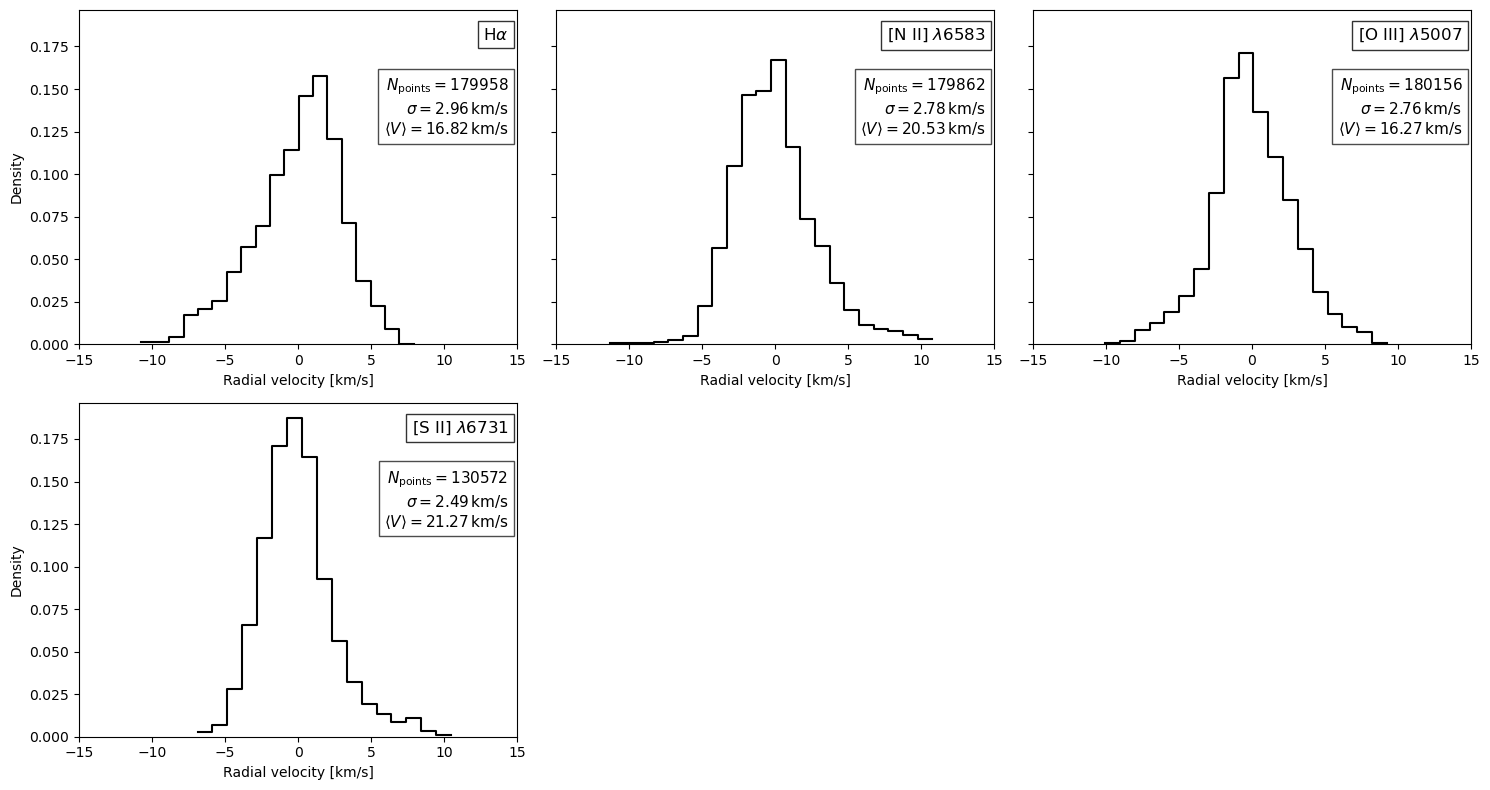

In [9]:
# Layout calculation
n_plots = len(data_all)
n_cols = 3  # Change for a wider grid
n_rows = math.ceil(n_plots / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharey=True)
axes = axes.flatten()

# Loop through datasets
for ax, name in zip(axes, data_all):
    df = processed_data[name].copy()
    df['RV_centered'] = df['VV'] - df['VV'].mean()

    sns.histplot(
        data=df,
        x="RV_centered",
        binwidth=1,
        element="step",
        fill=False,
        color='k',
        stat='density',
        ax=ax
        
    )

    # Pretty label and stats
    label = labels_dict.get(name, name)
    ax.text(0.98, 0.95, label, transform=ax.transAxes,
            ha='right', va='top', fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='k'))

    n_points = len(df)
    var_rv = df['RV_centered'].std()
    stats_text = f"$N_{{\\text{{points}}}} = {n_points}$\n$\\sigma = {var_rv:.2f}\\,\\mathrm{{km/s}}$\n$\\langle V \\rangle = {df['VV'].mean():.2f}\\,\\mathrm{{km/s}}$"
    ax.text(0.98, 0.80, stats_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=11, bbox=dict(facecolor='white', alpha=0.7))
    ax.set_xlim(-15,15)
    ax.set_xlabel("Radial velocity [km/s]")
  #  print(df['VV'].mean())
  #  print(var_rv)
  #  print(df['VV'].std())

# Remove unused axes if any
for i in range(n_plots, len(axes)):
    fig.delaxes(axes[i])

axes[0].set_ylabel("Density")
plt.tight_layout()
#plt.savefig("Imgs/pdfs_all.pdf", bbox_inches='tight')
plt.show()

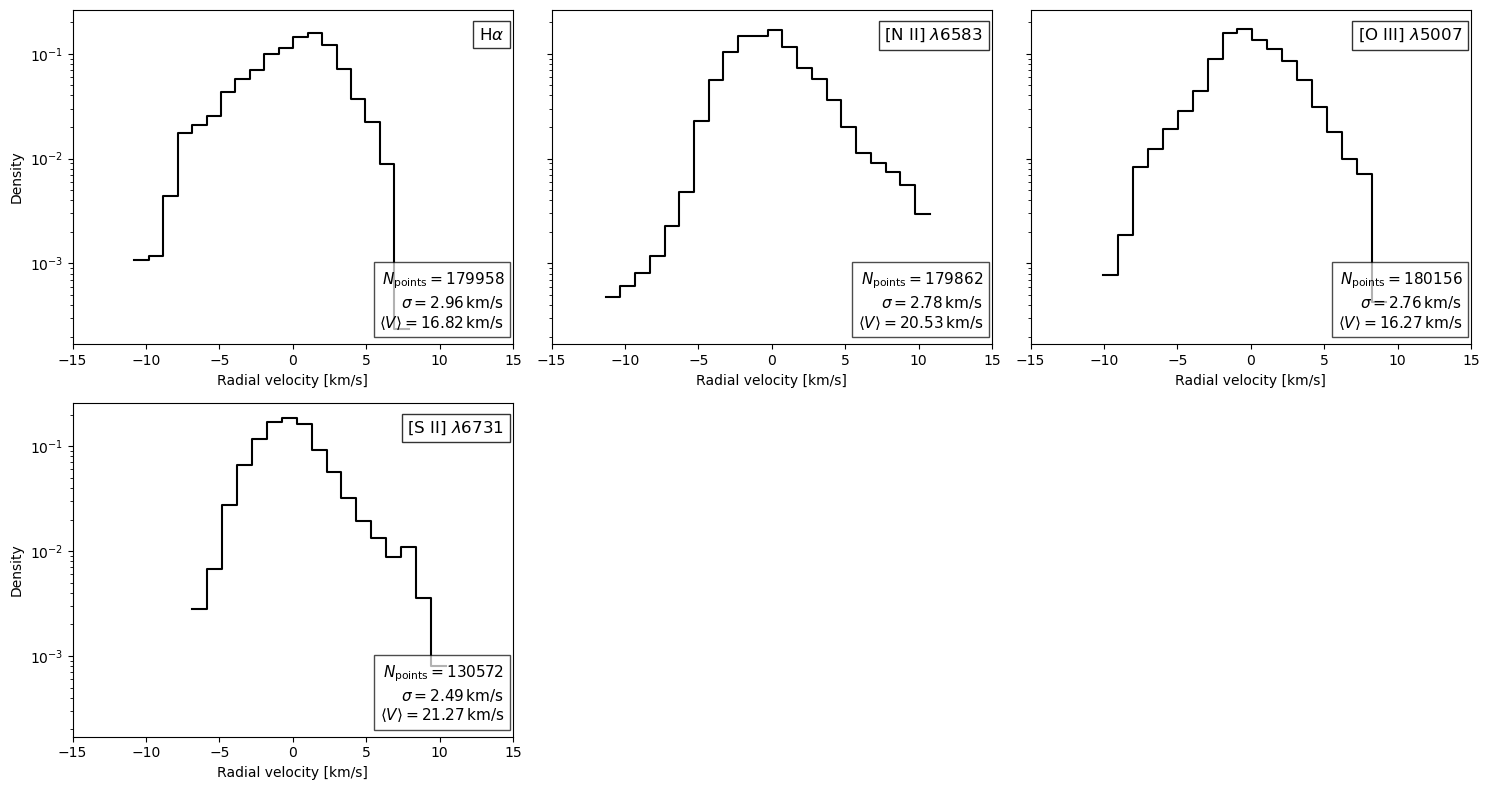

In [10]:
# Layout calculation
n_plots = len(data_all)
n_cols = 3  # Change for a wider grid
n_rows = math.ceil(n_plots / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharey=True)
axes = axes.flatten()

# Loop through datasets
for ax, name in zip(axes, data_all):
    df = processed_data[name].copy()
    df['RV_centered'] = df['VV'] - df['VV'].mean()

    sns.histplot(
        data=df,
        x="RV_centered",
        binwidth=1,
        element="step",
        fill=False,
        color='k',
        stat='density',
        ax=ax
        
    )
    ax.set_yscale("log")

    # Pretty label and stats
    label = labels_dict.get(name, name)
    ax.text(0.98, 0.95, label, transform=ax.transAxes,
            ha='right', va='top', fontsize=12, bbox=dict(facecolor='white', alpha=0.8, edgecolor='k'))

    n_points = len(df)
    var_rv = df['RV_centered'].std()
    stats_text = f"$N_{{\\text{{points}}}} = {n_points}$\n$\\sigma = {var_rv:.2f}\\,\\mathrm{{km/s}}$\n$\\langle V \\rangle = {df['VV'].mean():.2f}\\,\\mathrm{{km/s}}$"
    ax.text(0.98, 0.22, stats_text, transform=ax.transAxes,
            ha='right', va='top', fontsize=11, bbox=dict(facecolor='white', alpha=0.7))
    ax.set_xlim(-15,15)
    ax.set_xlabel("Radial velocity [km/s]")
  #  print(df['VV'].mean())
  #  print(var_rv)
  #  print(df['VV'].std())

# Remove unused axes if any
for i in range(n_plots, len(axes)):
    fig.delaxes(axes[i])

axes[0].set_ylabel("Density")
plt.tight_layout()
#plt.savefig("Imgs/pdfs_all.pdf", bbox_inches='tight')
plt.show()

C:\Users\javas\AppData\Local\Temp\ipykernel_2364\2195597820.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space on right for cbar


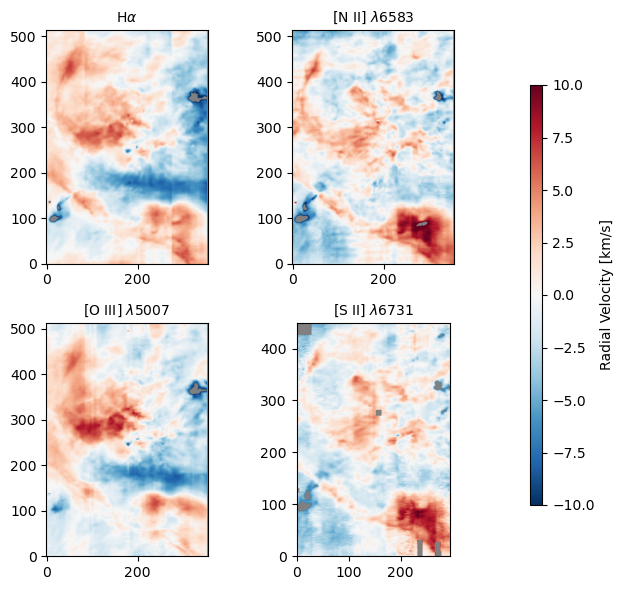

In [11]:
# Layout setup
n_plots = len(data_all)
n_cols = 2
n_rows = math.ceil(n_plots / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows), sharex=False, sharey=False)
axes = axes.flatten()

# Loop through datasets
im = None
for ax, name in zip(axes, data_all):
    vv = raw_data[name]["vv"] - np.nanmean(raw_data[name]["vv"])

    im = ax.imshow(vv, cmap='RdBu_r', origin='lower', vmin=-10, vmax=10)
    ax.set_title(labels_dict.get(name, name), fontsize=10)
    
    # Set black background for NaNs
    im.cmap.set_bad(color='gray')
#    ax.invert_yaxis()


# Remove unused axes
for i in range(n_plots, len(axes)):
    fig.delaxes(axes[i])

# Add colorbar in a manually defined axis (position = [left, bottom, width, height])
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # adjust as needed
fig.colorbar(im, cax=cbar_ax).set_label("Radial Velocity [km/s]")

plt.tight_layout(rect=[0, 0, 0.9, 1])  # leave space on right for cbar
#plt.savefig("Imgs/velocity_maps_shared_cbar_fixed.pdf", bbox_inches='tight')
plt.show()

In [12]:
processed_data[data_all[0]].describe()

,X,Y,VV,SB
count,179958.000000,179958.00000,179958.000000,179958.000000
mean,255.928606,176.33415,16.824079,0.276374
std,148.164126,101.38389,2.955181,0.156509
min,0.000000,1.00000,6.030076,0.005861
25%,128.000000,89.00000,15.032312,0.151952
50%,256.000000,176.00000,17.231346,0.252620
75%,385.000000,264.00000,18.866439,0.358672
max,512.000000,352.00000,24.722612,1.000000


In [13]:
offset_dict = {
    "KPNO-M42-H-bin0": {"x": 352//2, "y": 320},
    "KPNO-M42-N-bin0": {"x": 352//2, "y": 320},
    "KPNO-M42-O-bin0": {"x": 352//2, "y": 320},
    "KPNO-M42-S-bin0": {"x": 180, "y": 270},
}

C:\Users\javas\AppData\Local\Temp\ipykernel_2364\2562998961.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


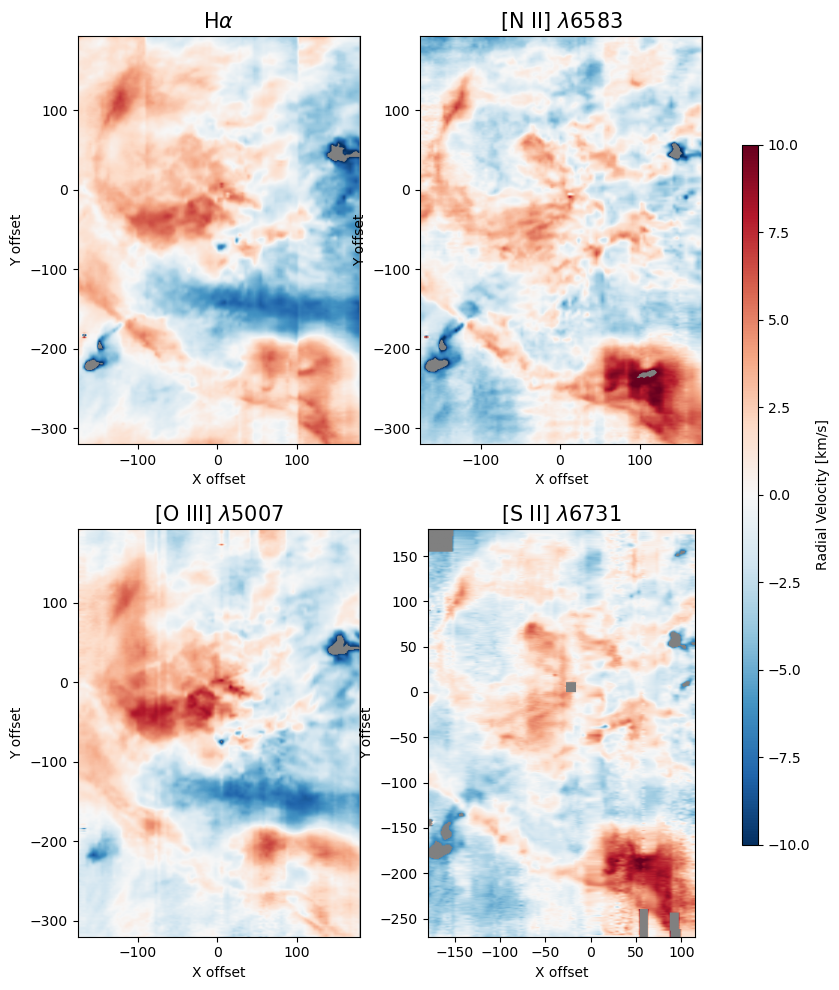

In [14]:
# Layout setup
n_plots = len(data_all)
n_cols = 2
n_rows = math.ceil(n_plots / n_cols)

# Create subplots
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 5 * n_rows),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

# Make a copy of the colormap so NaNs can be gray
cmap = plt.cm.RdBu_r.copy()
cmap.set_bad(color='gray')

# Loop through datasets
im = None

for ax, name in zip(axes, data_all):

    vv = raw_data[name]["vv"] - np.nanmean(raw_data[name]["vv"])
    vv = np.ma.masked_invalid(vv)

    ny, nx = vv.shape

    # Get x/y offset for this specific map
    x_offset = offset_dict[name]["x"]
    y_offset = offset_dict[name]["y"]

    # Shift image coordinates so that x_offset, y_offset become the zero point
    extent = [
        0 - x_offset,
        nx - x_offset,
        0 - y_offset,
        ny - y_offset
    ]

    im = ax.imshow(
        vv,
        cmap=cmap,
        origin='lower',
        vmin=-10,
        vmax=10,
        extent=extent,
        aspect='equal'
    )

    ax.set_title(labels_dict.get(name, name), fontsize=15)
    ax.set_xlabel("X offset")
    ax.set_ylabel("Y offset")

    # Optional reference lines at the new origin
   # ax.axhline(0, color='black', lw=0.7, zorder=3)
   # ax.axvline(0, color='black', lw=0.7, zorder=3)

# Remove unused axes
for i in range(n_plots, len(axes)):
    fig.delaxes(axes[i])

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax).set_label("Radial Velocity [km/s]")

plt.tight_layout(rect=[0, 0, 0.9, 1])

plt.show()

C:\Users\javas\AppData\Local\Temp\ipykernel_2364\1978928101.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


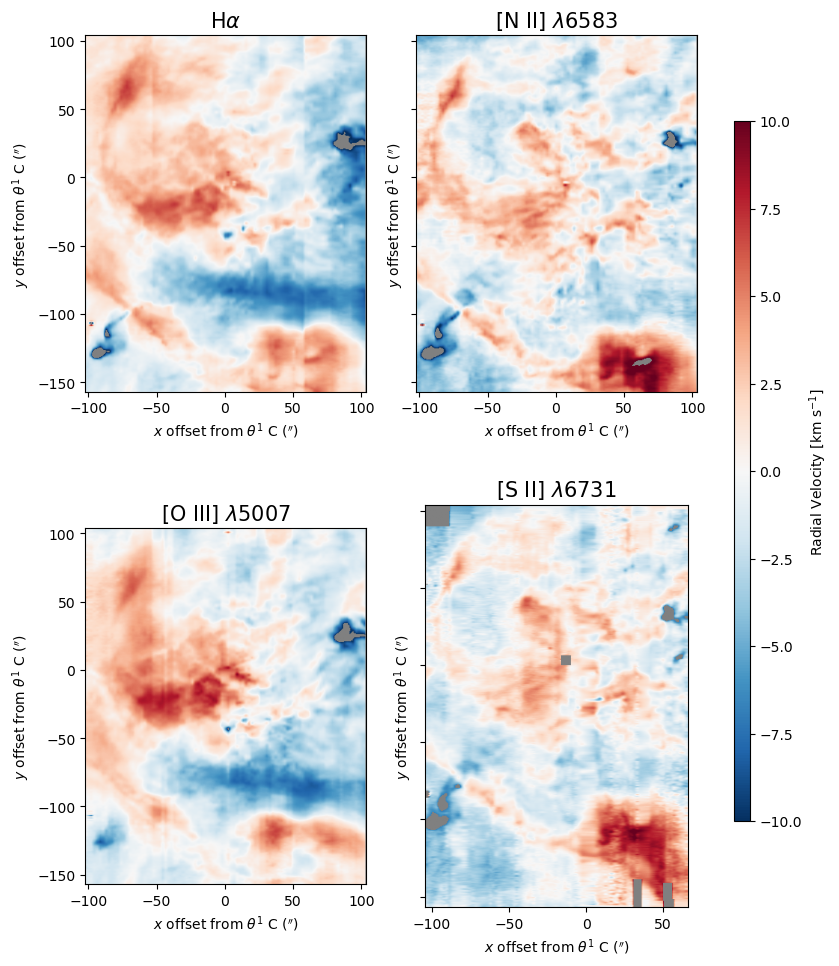

In [15]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Spatial sampling
pixscale = 0.58  # arcsec / pixel

# Layout setup
n_plots = len(data_all)
n_cols = 2
n_rows = math.ceil(n_plots / n_cols)

# Create subplots
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 5 * n_rows),
    sharex=False,
    sharey=True
)

axes = axes.flatten()

# Make a copy of the colormap so NaNs can be gray
cmap = plt.cm.RdBu_r.copy()
cmap.set_bad(color="gray")

# Loop through datasets
im = None

for ax, name in zip(axes, data_all):

    # Velocity map centered around its mean velocity
    vv = raw_data[name]["vv"] - np.nanmean(raw_data[name]["vv"])
    vv = np.ma.masked_invalid(vv)

    ny, nx = vv.shape

    # Offsets in pixels
    x_offset = offset_dict[name]["x"]
    y_offset = offset_dict[name]["y"]

    # Convert pixel coordinates to arcsec.
    # The -0.5 terms make the offset correspond to the center of a pixel.
    extent = [
        (-0.5        - x_offset) * pixscale,
        (nx - 0.5    - x_offset) * pixscale,
        (-0.5        - y_offset) * pixscale,
        (ny - 0.5    - y_offset) * pixscale,
    ]

    im = ax.imshow(
        vv,
        cmap=cmap,
        origin="lower",
        vmin=-10,
        vmax=10,
        extent=extent,
        aspect="equal"
    )

    ax.set_title(labels_dict.get(name, name), fontsize=15)

    ax.set_xlabel(r"$x$ offset from $\theta^1$ C ($^{\prime\prime}$)")
    ax.set_ylabel(r"$y$ offset from $\theta^1$ C ($^{\prime\prime}$)")

    # Optional reference lines at the new origin
    # ax.axhline(0, color="black", lw=0.7, zorder=3)
    # ax.axvline(0, color="black", lw=0.7, zorder=3)

# Remove unused axes
for i in range(n_plots, len(axes)):
    fig.delaxes(axes[i])

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])

cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(r"Radial Velocity [km s$^{-1}$]")

plt.tight_layout(rect=[0, 0, 0.9, 1])
#plt.savefig("Imgs/kpno_velocity_maps_shared_cbar_fixed.pdf", bbox_inches='tight')

plt.show()

In [20]:
processed_data[data_all[0]].describe()

,X,Y,VV,SB
count,179958.000000,179958.00000,179958.000000,179958.000000
mean,255.928606,176.33415,16.824079,0.276374
std,148.164126,101.38389,2.955181,0.156509
min,0.000000,1.00000,6.030076,0.005861
25%,128.000000,89.00000,15.032312,0.151952
50%,256.000000,176.00000,17.231346,0.252620
75%,385.000000,264.00000,18.866439,0.358672
max,512.000000,352.00000,24.722612,1.000000


In [19]:
processed_data[data_all[3]].describe()

,X,Y,VV,SB
count,130572.000000,130572.000000,130572.000000,130572.000000
mean,224.531622,147.528636,21.268425,0.010120
std,128.995120,84.380878,2.487448,0.005677
min,0.000000,0.000000,14.372275,0.001013
25%,113.000000,75.000000,19.635127,0.006359
50%,225.000000,147.000000,21.047139,0.009261
75%,336.000000,220.000000,22.484063,0.012411
max,449.000000,294.000000,31.729561,0.055266


C:\Users\javas\AppData\Local\Temp\ipykernel_2364\4124270910.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


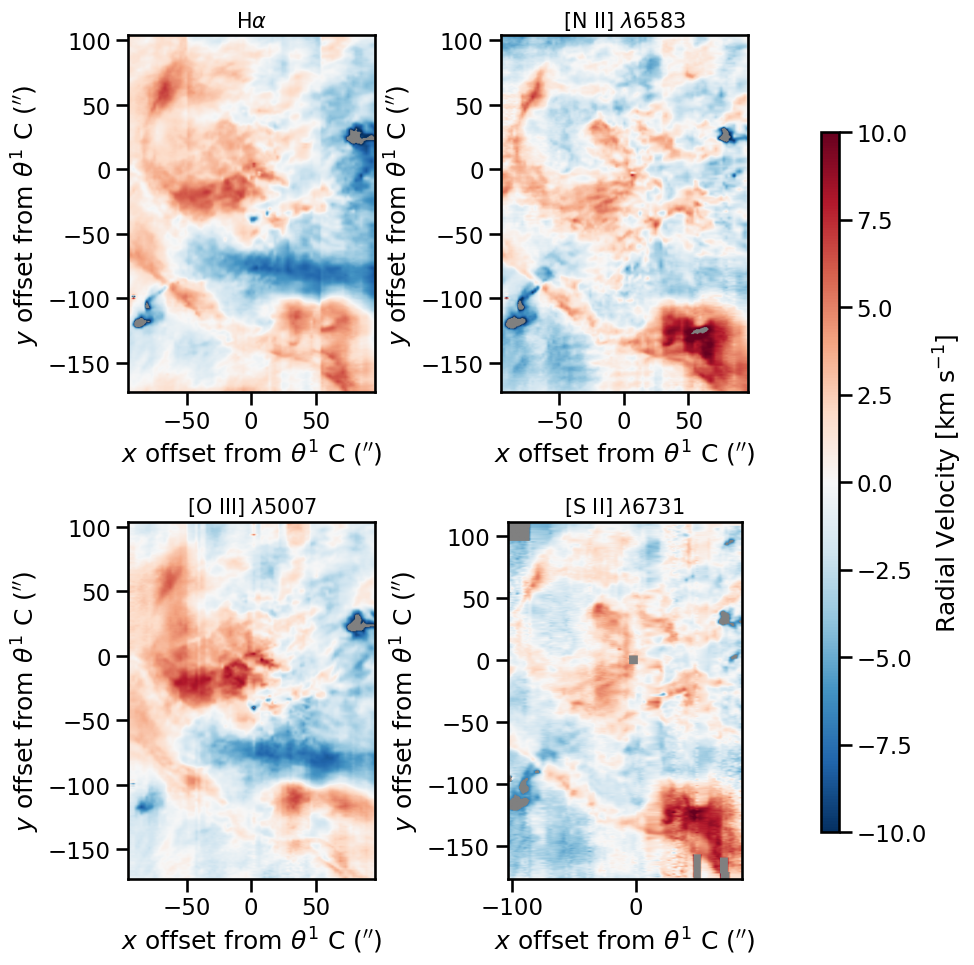

In [27]:
import math
import numpy as np
import matplotlib.pyplot as plt

sns.set_context("talk")


# Individual spatial sampling for each map
# Values are in arcsec / pixel
pixscale_dict = {
    "KPNO-M42-H-bin0": 0.54,
    "KPNO-M42-N-bin0": 0.54,
    "KPNO-M42-O-bin0": 0.54,
    "KPNO-M42-S-bin0": 0.64,
}

# Offsets in pixels
offset_dict = {
    "KPNO-M42-H-bin0": {"x": 352//2, "y": 320},
    "KPNO-M42-N-bin0": {"x": 352//2, "y": 320},
    "KPNO-M42-O-bin0": {"x": 352//2, "y": 320},
    "KPNO-M42-S-bin0": {"x": 161, "y": 275},
}

# Layout setup
n_plots = len(data_all)
n_cols = 2
n_rows = math.ceil(n_plots / n_cols)

# Create subplots
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4.5 * n_cols, 5 * n_rows),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

# Make a copy of the colormap so NaNs can be gray
cmap = plt.cm.RdBu_r.copy()
cmap.set_bad(color="gray")

# Loop through datasets
im = None

for ax, name in zip(axes, data_all):

    # Velocity map centered around its mean velocity
    vv = raw_data[name]["vv"] - np.nanmean(raw_data[name]["vv"])
    vv = np.ma.masked_invalid(vv)

    ny, nx = vv.shape

    # Offset for this specific map, in pixels
    x_offset = offset_dict[name]["x"]
    y_offset = offset_dict[name]["y"]

    # Pixel scale for this specific map, in arcsec / pixel
    pixscale = pixscale_dict[name]

    # Convert pixel coordinates to arcsec.
    # The -0.5 terms make the offset correspond to the center of a pixel.
    extent = [
        (-0.5      - x_offset) * pixscale,
        (nx - 0.5  - x_offset) * pixscale,
        (-0.5      - y_offset) * pixscale,
        (ny - 0.5  - y_offset) * pixscale,
    ]

    im = ax.imshow(
        vv,
        cmap=cmap,
        origin="lower",
        vmin=-10,
        vmax=10,
        extent=extent,
        aspect="equal"
    )

    ax.set_title(labels_dict.get(name, name), fontsize=15)

    ax.set_xlabel(r"$x$ offset from $\theta^1$ C ($^{\prime\prime}$)")
    ax.set_ylabel(r"$y$ offset from $\theta^1$ C ($^{\prime\prime}$)")

    # Optional reference lines at the new origin
    # ax.axhline(0, color="black", lw=0.7, zorder=3)
    # ax.axvline(0, color="black", lw=0.7, zorder=3)

# Remove unused axes
for i in range(n_plots, len(axes)):
    fig.delaxes(axes[i])

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])

cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label(r"Radial Velocity [km s$^{-1}$]")

plt.tight_layout(rect=[0, 0, 0.9, 1])

# Export figure
plt.savefig("Imgs/kpno_velocity_maps_shared_cbar_fixed.pdf", bbox_inches="tight")

plt.show()

In [17]:
xxx

NameError: name 'xxx' is not defined

In [ ]:
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
import astropy.units as u
c0 = SkyCoord.from_name("Orion")
c0

In [ ]:
size_dict = {
    "KPNO-M42-H-bin0": {"x": 352, "y": 512},
    "KPNO-M42-N-bin0": {"x": 352, "y": 512},
    "KPNO-M42-O-bin0": {"x": 352, "y": 512},
  #  "KPNO-M42-S-bin0": {"x": 295, "y": 350},
    "KPNO-M42-S-bin0": {"x": 295, "y": 350*1.1},
}

In [ ]:
sns.set_context("talk")


# Layout setup
n_plots = len(data_all)
n_cols = 2
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.4 * n_cols, 4 * n_rows),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

# Colormap for NaNs
cmap = plt.cm.RdBu_r.copy()
cmap.set_bad(color='gray')

# First compute extents for all maps
extent_dict = {}

for name in data_all:
    x_size = size_dict[name]["x"]
    y_size = size_dict[name]["y"]

    # If your zero-point is the center of each map:
    extent_dict[name] = [
        -x_size ,
         x_size ,
        -y_size ,
         y_size 
    ]

# Global limits so all maps are shown on the same scale
x_min = min(ext[0] for ext in extent_dict.values())
x_max = max(ext[1] for ext in extent_dict.values())
y_min = min(ext[2] for ext in extent_dict.values())
y_max = max(ext[3] for ext in extent_dict.values())

im = None

for ax, name in zip(axes, data_all):

    vv = raw_data[name]["vv"] - np.nanmean(raw_data[name]["vv"])
    vv = np.ma.masked_invalid(vv)

    im = ax.imshow(
        vv,
        cmap=cmap,
        origin='lower',
        vmin=-10,
        vmax=10,
        extent=extent_dict[name],
        aspect='equal'
    )

    ax.set_title(labels_dict.get(name, name), fontsize=14)

    # Force every subplot to use the same coordinate system
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # Optional: gray background outside the actual image extent
    ax.set_facecolor("gray")

    # Optional reference lines
    #ax.axhline(0, color='black', lw=0.7, zorder=3)
    #ax.axvline(0, color='black', lw=0.7, zorder=3)

# Remove unused axes
for i in range(n_plots, len(axes)):
    fig.delaxes(axes[i])

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax).set_label("Radial Velocity [km/s]")

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

In [ ]:
# Layout setup
n_plots = len(data_all)
n_cols = 2
n_rows = math.ceil(n_plots / n_cols)

# Create subplots
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.5 * n_cols, 4 * n_rows),
    sharex=False,
    sharey=False
)

axes = axes.flatten()

# Make a copy of the colormap so NaNs can be gray
cmap = plt.cm.RdBu_r.copy()
cmap.set_bad(color='gray')

# -------------------------------------------------------
# First pass: compute extents for every map
# -------------------------------------------------------
extent_dict = {}

for name in data_all:

    vv = raw_data[name]["vv"]
    ny, nx = vv.shape

    x_offset = offset_dict[name]["x"]
    y_offset = offset_dict[name]["y"]

    extent_dict[name] = [
        0 - x_offset,
        nx - x_offset,
        0 - y_offset,
        ny - y_offset
    ]

# Global limits from all maps
x_min = min(ext[0] for ext in extent_dict.values())
x_max = max(ext[1] for ext in extent_dict.values())
y_min = min(ext[2] for ext in extent_dict.values())
y_max = max(ext[3] for ext in extent_dict.values())

# -------------------------------------------------------
# Second pass: plot maps
# -------------------------------------------------------
im = None

for ax, name in zip(axes, data_all):

    vv = raw_data[name]["vv"] - np.nanmean(raw_data[name]["vv"])
    vv = np.ma.masked_invalid(vv)

    im = ax.imshow(
        vv,
        cmap=cmap,
        origin='lower',
        vmin=-10,
        vmax=10,
        extent=extent_dict[name],
        aspect='equal'
    )

    ax.set_title(labels_dict.get(name, name), fontsize=10)
    ax.set_xlabel("X offset")
    ax.set_ylabel("Y offset")

    # Force all panels to have the same coordinate system
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # Background outside smaller maps
    ax.set_facecolor("gray")

    # Optional reference lines
    # ax.axhline(0, color='black', lw=0.7, zorder=3)
    # ax.axvline(0, color='black', lw=0.7, zorder=3)

# Remove unused axes
for i in range(n_plots, len(axes)):
    fig.delaxes(axes[i])

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax).set_label("Radial Velocity [km/s]")

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()